In [162]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
import glob, os, sys

from data.movie import Frames, Audio #, People Measures
from data.spikes import Rates # LFP, BOLD
from data.behavior import Gaze, Suspense # Suspense, Valence, Arousal

from tqdm import tqdm


### suspense

In [163]:
FRs, suspense = Rates(), Suspense()

rescale_t = 1
FRs, suspense = FRs.rescale(rescale_t), suspense.rescale(rescale_t)
FRs.shape, suspense.shape

avg_suspense = suspense.mean(axis=1)

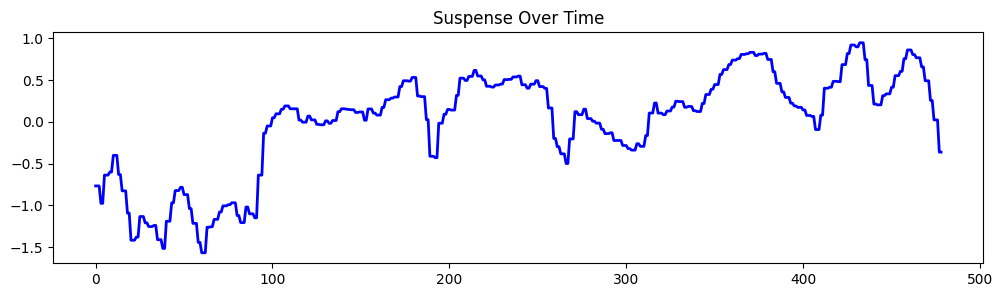

In [164]:
plt.figure(figsize=(12, 3))
plt.title('Suspense Over Time')
plt.plot(avg_suspense, color='blue', linewidth=2)
plt.show()

### audio

In [165]:
audio = Audio()
audio_metrics = [
    audio.instruments.volume,
    audio.instruments.timbre,
    audio.vocals.volume,
    audio.vocals.timbre,
    audio.vocals.arousal,
    audio.vocals.dominance,
    audio.vocals.valence,
    audio.vocals.angry,
    audio.vocals.sad,
    audio.vocals.happy,
    audio.vocals.surprise,
    audio.vocals.fear,
    audio.vocals.disgust,
    audio.vocals.contempt,
    audio.vocals.neutral,
]

In [166]:
# apply rescaling and stack into a matrix
rescaled_metrics = [data.rescale(1) for data in audio_metrics]
X = np.stack(rescaled_metrics, axis=1)  # shape: (n_timepoints, n_features)

# build DataFrame with names
colnames = [
    'instr_vol', 'instr_timbre',
    'voc_vol', 'voc_timbre',
    'arousal', 'dominance', 'valence',
    'angry', 'sad', 'happy', 'surprise',
    'fear', 'disgust', 'contempt', 'neutral',
]
df = pd.DataFrame(X, columns=colnames)

# df['suspense'] = Suspense().rescale(1).mean(axis=1)

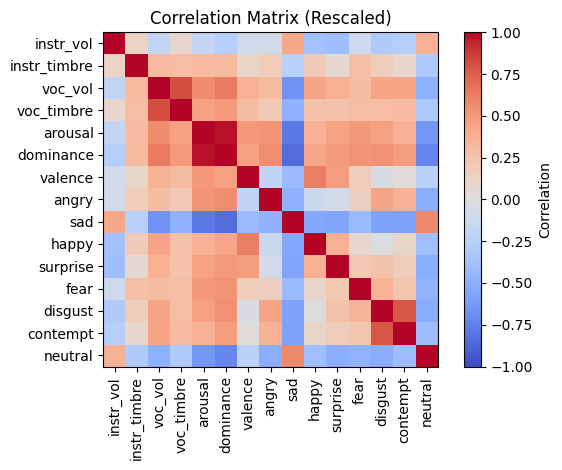

In [167]:
# plot correlation matrix
corr = df.corr()
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title('Correlation Matrix (Rescaled)')
plt.tight_layout()
plt.show()


In [168]:
sensory_output = df.prod(axis=1)  # shape: (n_timepoints,)

### firing rates

In [169]:
FRs = Rates().rescale(1)
FRs

,Left_ACC_P58CS_R1_1_1_994_6,Right_ACC_P58CS_R1_35_2_2425_5,Right_ACC_P58CS_R1_35_1_2195_5,Right_ACC_P58CS_R1_34_4_3301_5,Right_ACC_P58CS_R1_34_3_3299_5,Right_ACC_P58CS_R1_34_2_3239_5,Right_ACC_P58CS_R1_34_1_3232_5,Right_ACC_P58CS_R1_36_1_712_5,Right_ACC_P58CS_R1_36_2_962_5,Right_ACC_P58CS_R1_38_1_1473_5,...,Right_amygdala_P62CS_R1_28_1_6059_3,Right_amygdala_P62CS_R1_27_3_8498_3,Right_preSMA_P62CS_R1_22_3_2598_7,Right_preSMA_P62CS_R1_22_2_2532_7,Right_preSMA_P62CS_R1_22_1_2407_7,Right_preSMA_P62CS_R1_18_3_3847_7,Right_preSMA_P62CS_R1_18_2_3846_7,Right_preSMA_P62CS_R1_18_1_3830_7,Right_vmPFC_P62CS_R1_7_1_791_9,Right_vmPFC_P62CS_R1_5_1_1374_9
0.0,-1.180952,-0.666667,-0.038095,-7.571838,0.573146,-0.180843,-0.476190,0.795238,0.476495,0.766888,...,-0.095238,0.0,-0.790561,-1.066667,-0.095238,0.094940,6.925359,-1.447619,-0.777148,-0.146550
1.0,-1.180952,-0.666667,-0.038095,-8.202274,-1.276910,0.696879,-0.476190,1.023172,2.044693,3.017722,...,-0.095238,0.0,-0.630207,-1.066518,-0.095238,0.197187,1.132730,-1.447619,-0.008835,-0.693488
2.0,-1.180952,-0.666667,-0.038095,-1.101670,-0.291149,1.215248,-0.476042,2.343321,1.756937,0.573081,...,-0.095238,0.0,2.944444,-0.732895,-0.095238,-0.828569,4.641910,-1.447619,-0.382118,-0.698561
3.0,-1.180952,-0.666667,-0.038095,16.731459,0.516851,0.797838,0.357031,0.713225,1.656819,2.021726,...,-0.095238,0.0,-1.361343,-0.483885,-0.095238,0.374791,2.576883,-1.447619,0.048688,-0.520191
4.0,-1.180952,-0.666667,-0.038095,4.201117,-1.605757,-0.936392,0.629848,0.032041,0.411422,0.199649,...,-0.095238,0.0,-1.493237,-1.066369,-0.095238,-0.624775,1.638817,-1.447619,0.205105,0.772155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474.0,-1.180952,-0.666444,-0.038095,0.259806,-0.260076,0.245400,0.106591,-0.038095,-0.405524,-0.899779,...,-0.095238,0.0,1.178466,-0.812422,-0.095238,-0.522212,4.394781,0.020986,0.388416,0.104934
475.0,-1.180952,0.065940,0.026968,-2.397802,-0.296222,0.587232,-0.142419,-0.038095,0.346359,0.028604,...,-0.095238,0.0,1.556020,-0.294400,-0.095238,-1.002982,-2.216291,0.639553,0.390149,1.657467
476.0,-1.180952,1.858703,1.007953,-0.770127,-1.277058,0.503567,-0.470969,-0.038095,1.118477,-0.887318,...,-0.095238,0.0,-1.661036,-0.334060,-0.090165,1.441956,-0.000958,-0.649801,0.599016,0.542973
477.0,-1.180952,-0.027478,0.791433,5.790031,-0.260187,1.712850,0.554981,0.010702,0.424004,-0.952381,...,-0.095238,0.0,0.374543,0.296958,0.685493,-0.887434,-1.216143,0.166446,0.048688,1.269342


### forming conds

In [180]:
# high_mask, low_mask = avg_suspense > threshold,  avg_suspense <= threshold
# high_times, low_times = np.where(high_mask)[0], np.where(low_mask)[0]
sensory_cond = (sensory_output > np.percentile(sensory_output, 50)).astype(int)
suspense_cond = (avg_suspense > np.percentile(avg_suspense, 50)).astype(int)

sen_sus_conds = sensory_cond * 2 + suspense_cond # resulting in 0,1,2,3
unique, counts = np.unique(sen_sus_conds, return_counts=True)

cond_counts = dict(zip(unique, counts))
cond_names = {
    0: 'Low Sensory, Low Suspense',
    1: 'Low Sensory, High Suspense',
    2: 'High Sensory, Low Suspense',
    3: 'High Sensory, High Suspense'
}

for cond in range(4):
    print(f'{cond_names[cond]} pts: {cond_counts[cond]}')

sen_sus_conds.shape

Low Sensory, Low Suspense pts: 138
Low Sensory, High Suspense pts: 102
High Sensory, Low Suspense pts: 103
High Sensory, High Suspense pts: 136


(479,)

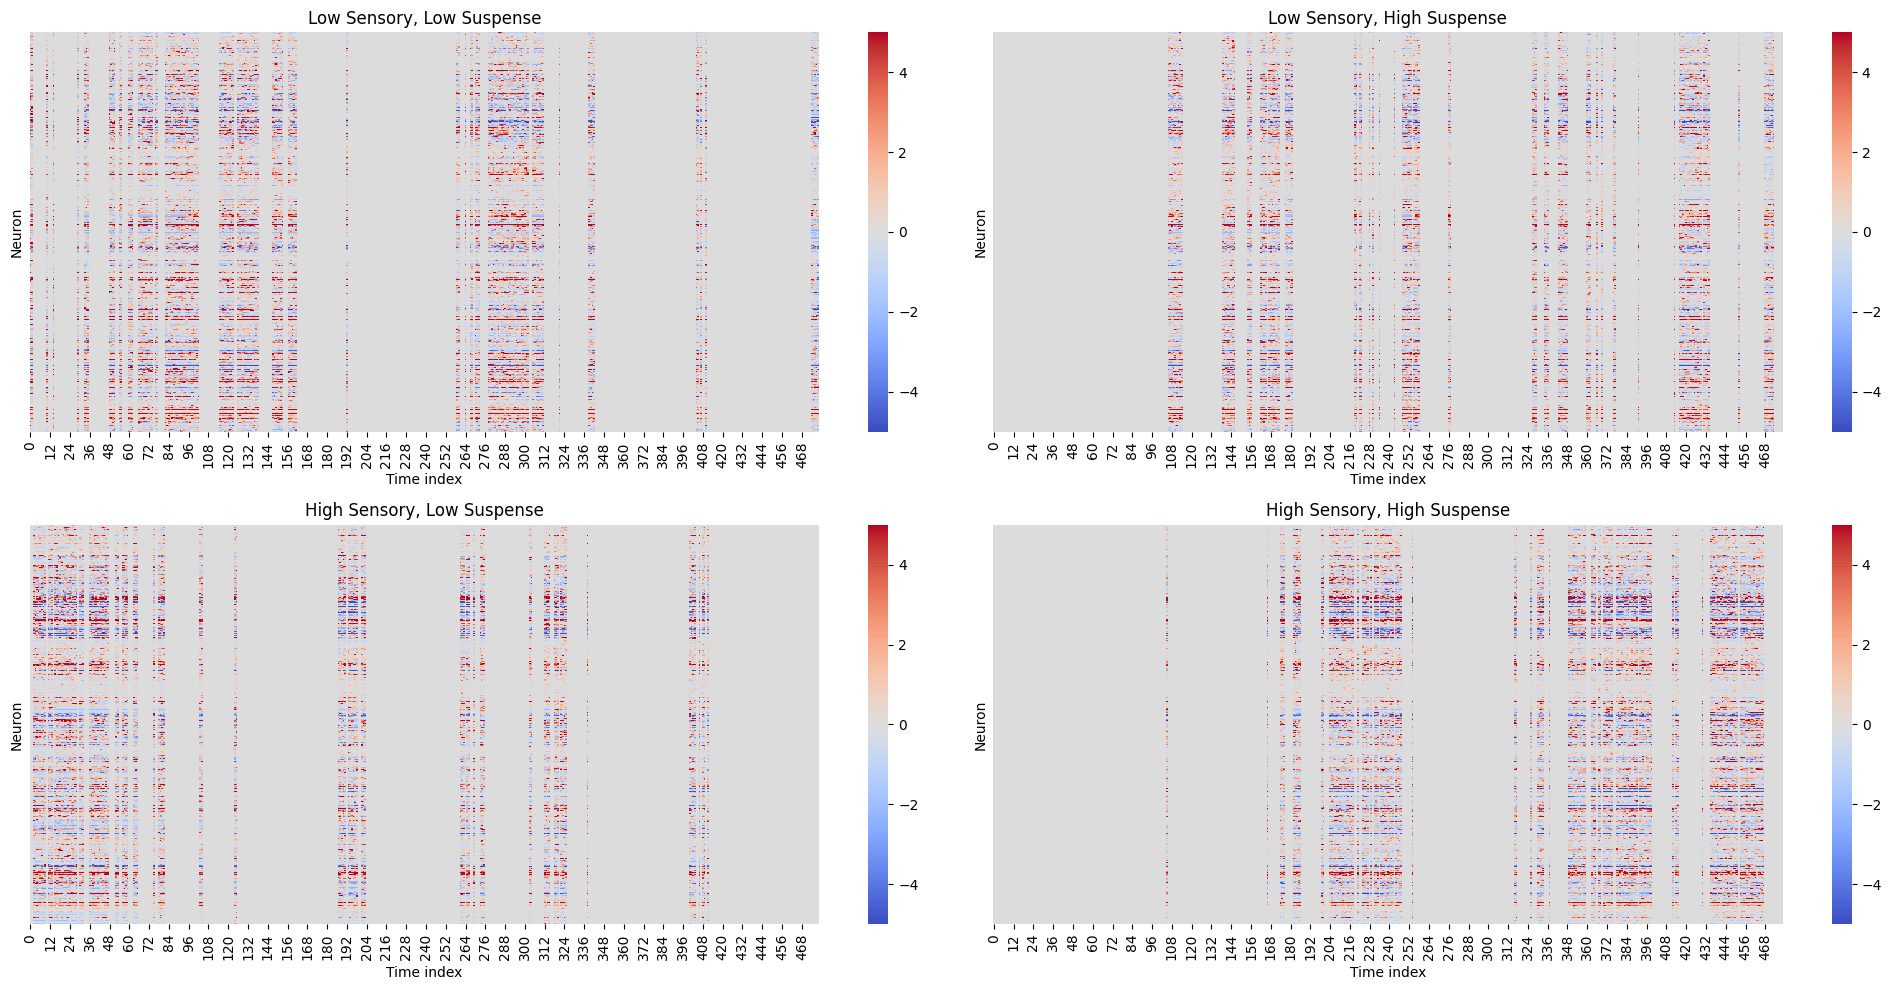

In [184]:
fig, axs = plt.subplots(2, 2, figsize=(20, 10))
axs, ax = axs.ravel(), 0
FR_plt_rng = 5

for cond in range(4):

    FR_arr = FRs.copy().values

    # set all FRs, except for the current sen_sus_cond, to 0
    FR_arr[sen_sus_conds != cond, :] = 0

    sns.heatmap(FR_arr.T, cmap='coolwarm', ax=axs[ax], vmin=-FR_plt_rng, vmax=FR_plt_rng)
    axs[ax].set(title=f'{cond_names[cond]}', xlabel='Time index', ylabel='Neuron', yticks=[])
    ax += 1

plt.tight_layout()
plt.show()

In [177]:
# minmax = lambda x: (x - x.min()) / (x.max() - x.min())

# fig, axs = plt.subplots(1, 1, figsize=(20, 4))
# FR_plt_rng = 20

# FR_arr = FRs.copy().values

# val = FR_arr[(sen_sus_levels == 1) + (sen_sus_levels == 3), :] = 0

# sns.heatmap(FR_arr.T, cmap='coolwarm', cbar=True, ax=axs, vmin=-FR_plt_rng, vmax=FR_plt_rng)
# axs.plot(minmax(avg_suspense)* 1400, color='blue', linewidth=2)

# axs.axhline(y=np.median(minmax(avg_suspense)* 1400), color='k', linestyle='--', linewidth=1)

# # axs.set(title=f'{label_dict[sen_sus_level]}', xlabel='Time index', ylabel='Neuron', yticks=[])
# plt.tight_layout()
# plt.show()

### GLMs